# Ecommerce Company Analysis

## 1. Importing Library

In [1]:
# Thư viện data manipulation
import numpy as np
import pandas as pd
# Thư viện visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
#Thư viện xử lý đường dẫn
import os
import glob

## 2. Imporing Raw Data

In [2]:
# Import các file CSV gốc vào DataFrame
# Khai báo đường dẫn đến thư mục chứa data
data_path = r"D:\VinUni Datathon Python\dataset"

# Lấy danh sách tất cả các đường dẫn file .csv trong thư mục
csv_files = glob.glob(os.path.join(data_path, "*.csv"))

# Khởi tạo một dictionary để chứa các DataFrame
dfs = {}

for file in csv_files:
    table_name = os.path.basename(file).replace('.csv', '')
    # Đọc file CSV và lưu vào dictionary
    try:
        dfs[table_name] = pd.read_csv(file)
        print(f"Đã tải thành công bảng: '{table_name}' với kích thước {dfs[table_name].shape}")
    except Exception as e:
        print(f"Lỗi khi tải bảng {table_name}: {e}")

print(f"\nTổng cộng đã tải {len(dfs)} file CSV.")

# Khai báo các biến 
df_orders = dfs.get('orders')
df_order_items = dfs.get('order_items')
df_products = dfs.get('products')
df_customers = dfs.get('customers')
df_promotions = dfs.get('promotions')
df_shipments = dfs.get('shipments')
df_inventory = dfs.get('inventory')
df_returns = dfs.get('returns')
df_web_traffic = dfs.get('web_traffic')
df_geography = dfs.get('geography')
df_reviews = dfs.get('reviews')
df_payments = dfs.get('payments')
df_sales = dfs.get('sales')

print("-" * 40)
print("Đã gán xong các biến DataFrame")

Đã tải thành công bảng: 'customers' với kích thước (121930, 7)
Đã tải thành công bảng: 'geography' với kích thước (39948, 4)
Đã tải thành công bảng: 'inventory' với kích thước (60247, 17)
Đã tải thành công bảng: 'orders' với kích thước (646945, 8)


C:\Users\Phanv\AppData\Local\Temp\ipykernel_14332\2264264482.py:15: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs[table_name] = pd.read_csv(file)


Đã tải thành công bảng: 'order_items' với kích thước (714669, 7)
Đã tải thành công bảng: 'payments' với kích thước (646945, 4)
Đã tải thành công bảng: 'products' với kích thước (2412, 8)
Đã tải thành công bảng: 'promotions' với kích thước (50, 10)
Đã tải thành công bảng: 'returns' với kích thước (39939, 7)
Đã tải thành công bảng: 'reviews' với kích thước (113551, 7)
Đã tải thành công bảng: 'sales' với kích thước (3833, 3)
Đã tải thành công bảng: 'shipments' với kích thước (566067, 4)
Đã tải thành công bảng: 'web_traffic' với kích thước (3652, 7)

Tổng cộng đã tải 13 file CSV.
----------------------------------------
Đã gán xong các biến DataFrame


## 3. DATA CLEANING AND QUALITY CHECKING

### 3.1 CHECKING RAW DATA QUALITY

### 3.1.1 DUPLICATE

In [3]:
# DUPLICATE
for table_name, df in dfs.items():
    print(f"    BẢNG: {table_name.upper()}    ")
    duplicate = df.duplicated().sum()
    print(f"Trùng lặp: {duplicate} dòng")
    print("\n")

    BẢNG: CUSTOMERS    
Trùng lặp: 0 dòng


    BẢNG: GEOGRAPHY    
Trùng lặp: 0 dòng


    BẢNG: INVENTORY    
Trùng lặp: 0 dòng


    BẢNG: ORDERS    
Trùng lặp: 0 dòng


    BẢNG: ORDER_ITEMS    
Trùng lặp: 0 dòng


    BẢNG: PAYMENTS    
Trùng lặp: 0 dòng


    BẢNG: PRODUCTS    
Trùng lặp: 0 dòng


    BẢNG: PROMOTIONS    
Trùng lặp: 0 dòng


    BẢNG: RETURNS    
Trùng lặp: 0 dòng


    BẢNG: REVIEWS    
Trùng lặp: 0 dòng


    BẢNG: SALES    
Trùng lặp: 0 dòng


    BẢNG: SHIPMENTS    
Trùng lặp: 0 dòng


    BẢNG: WEB_TRAFFIC    
Trùng lặp: 0 dòng




### 3.1.2 MISSING VALUE

In [4]:
# MISSING VALUE
for table_name, df in dfs.items():
    print(f"    BẢNG: {table_name.upper()}    ")
    print("Thống kê Null:")
    print(df.isnull().sum())
    print("\n")

    BẢNG: CUSTOMERS    
Thống kê Null:
customer_id            0
zip                    0
city                   0
signup_date            0
gender                 0
age_group              0
acquisition_channel    0
dtype: int64


    BẢNG: GEOGRAPHY    
Thống kê Null:
zip         0
city        0
region      0
district    0
dtype: int64


    BẢNG: INVENTORY    
Thống kê Null:
snapshot_date        0
product_id           0
stock_on_hand        0
units_received       0
units_sold           0
stockout_days        0
days_of_supply       0
fill_rate            0
stockout_flag        0
overstock_flag       0
reorder_flag         0
sell_through_rate    0
product_name         0
category             0
segment              0
year                 0
month                0
dtype: int64


    BẢNG: ORDERS    
Thống kê Null:
order_id          0
order_date        0
customer_id       0
zip               0
order_status      0
payment_method    0
device_type       0
order_source      0
dtype: int64


    B

### 3.1.3 OUTLIERS

#### 3.1.3.1 Transaction Outliers

BÁO CÁO KIỂM TRA TRANSACTION OUTLIERS

Đánh giá số lượng Outlier theo chuẩn IQR:

  -> Cột 'quantity': Phát hiện 0 dòng ngoại lai.
     + Thông số IQR: Q1 = 2.0, Q3 = 6.0 => IQR = 4.0
     + LÝ DO LÀ NGOẠI LAI: 
       Các dòng này vượt qua ranh giới trên của phân phối dữ liệu chuẩn (Tính bằng công thức Q3 + 1.5*IQR)
       Cụ thể là mua nhiều hơn 12.0 sản phẩm/đơn hàng, trong khi phần lớn đơn hàng chỉ mua dưới 6.0 sản phẩm

  -> Cột 'unit_price': Phát hiện 8623 dòng ngoại lai.
     + Thông số IQR: Q1 = 1,906.9, Q3 = 7,273.8 => IQR = 5,366.9
     + LÝ DO LÀ NGOẠI LAI:
       Thuộc nhóm giá trị đắt bất thường, vượt qua ranh giới trên (Q3 + 1.5*IQR)
       Cụ thể là có giá đắt hơn 15,324.1 VNĐ, trong khi phần lớn sản phẩm có giá dưới 7,273.8 VNĐ

  -> Cột 'shipping_fee': Phát hiện 76050 dòng ngoại lai.
     + Thông số IQR: Q1 = 0.9, Q3 = 2.6 => IQR = 1.7
     + LÝ DO LÀ NGOẠI LAI:
       Phí ship cao đột biến, vượt giới hạn an toàn thống kê (Q3 + 1.5*IQR)
       Cụ thể là cao hơn 5.2 VNĐ

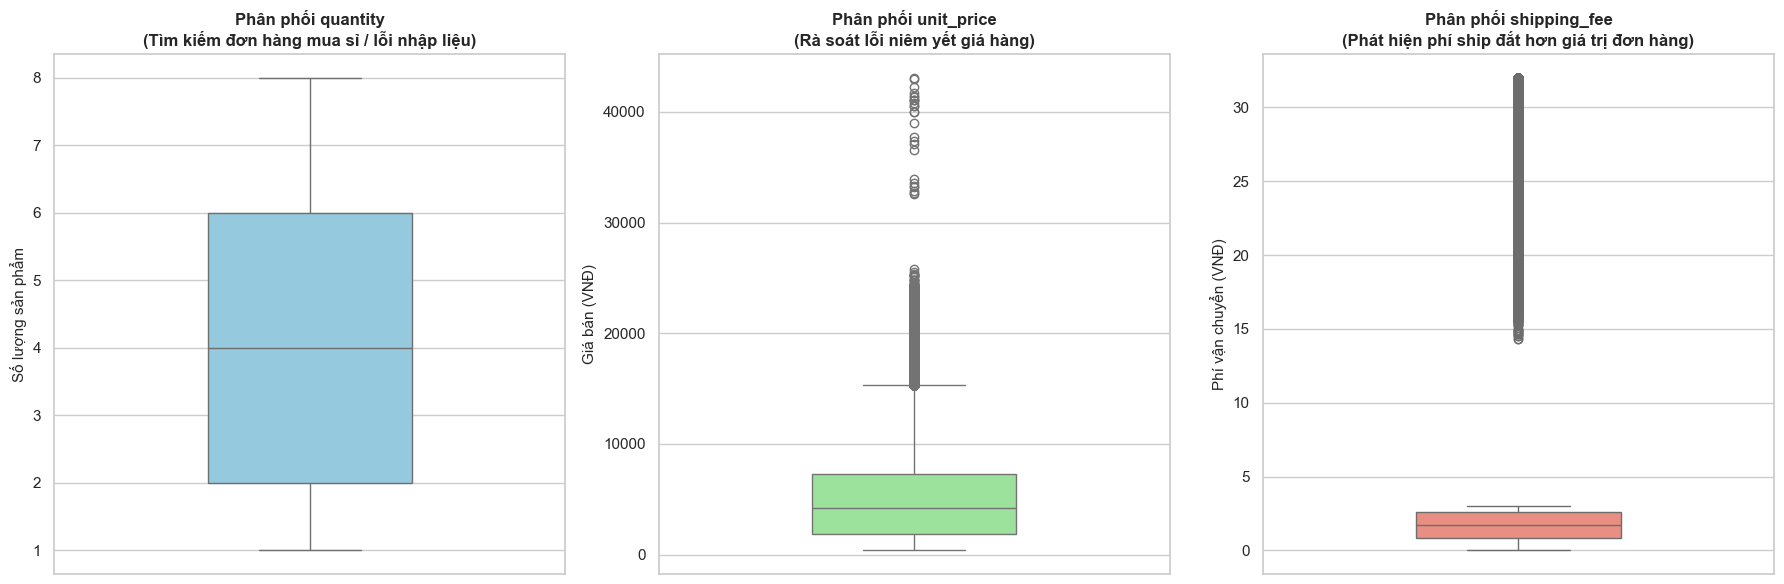


Kết luận

+ [quantity]: Những chấm đen nằm tít phía trên râu biểu đồ là các đơn hàng có số lượng cực lớn
               Khả năng cao đây là tệp khách hàng mua sỉ (B2B)
               Chúng ta KHÔNG NÊN XÓA, mà cần gán nhãn tệp khách này thành 'Cá Voi' để phân tích Lợi nhuận riêng biệt

+ [unit_price]: Xuất hiện các sản phẩm có mức giá cao đột biến so với phần còn lại
                 Đây có thể là các dòng sản phẩm giới hạn (Premium/Limited edition) giúp kéo lại Profit Margin, hoặc đơn thuần là lỗi nhập liệu dư thừa số 0
                 Cần cross-check với bảng products

+ [shipping_fee]: Phát hiện nhiều đơn hàng có phí ship rải rác trên rất cao
                   Cần liên kết nhanh giá trị phí ship này với giá trị thực của món hàng
                   Nếu phí ship > giá trị hàng hóa, đây chính là dấu hiệu rõ rệt của sự rò rỉ chi phí cắn vào Net Profit


In [5]:
print("BÁO CÁO KIỂM TRA TRANSACTION OUTLIERS\n" + "="*60)
# Các metric cần kiểm tra Outlier: quantity, unit_price, shipping_fee
# 1. Check Outliers bằng IQR
def check_outliers_iqr(df, column):
    # Loại bỏ giá trị Null trước khi tính toán để tránh lỗi
    s = df[column].dropna()
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    
    # Ranh giới trên và dưới
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Đếm số lượng
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    
    # TRẢ VỀ THÊM CÁC THAM SỐ TOÁN HỌC ĐỂ GIẢI THÍCH LÝ DO
    return len(outliers), upper_bound, lower_bound, Q1, Q3, IQR

# Quét qua bảng order_items (quantity va unit_price)
qty_outliers, qty_limit, qty_lower, qty_q1, qty_q3, qty_iqr = check_outliers_iqr(df_order_items, 'quantity')
price_outliers, price_limit, price_lower, price_q1, price_q3, price_iqr = check_outliers_iqr(df_order_items, 'unit_price')

# Quét qua bảng shipments (shipping_fee)
ship_outliers, ship_limit, ship_lower, ship_q1, ship_q3, ship_iqr = check_outliers_iqr(df_shipments, 'shipping_fee')

print("\nĐánh giá số lượng Outlier theo chuẩn IQR:")

print(f"\n  -> Cột 'quantity': Phát hiện {qty_outliers} dòng ngoại lai.")
print(f"     + Thông số IQR: Q1 = {qty_q1:,.1f}, Q3 = {qty_q3:,.1f} => IQR = {qty_iqr:,.1f}")
print(f"     + LÝ DO LÀ NGOẠI LAI: ")
print(f"       Các dòng này vượt qua ranh giới trên của phân phối dữ liệu chuẩn (Tính bằng công thức Q3 + 1.5*IQR)")
print(f"       Cụ thể là mua nhiều hơn {qty_limit:,.1f} sản phẩm/đơn hàng, trong khi phần lớn đơn hàng chỉ mua dưới {qty_q3:,.1f} sản phẩm")

print(f"\n  -> Cột 'unit_price': Phát hiện {price_outliers} dòng ngoại lai.")
print(f"     + Thông số IQR: Q1 = {price_q1:,.1f}, Q3 = {price_q3:,.1f} => IQR = {price_iqr:,.1f}")
print(f"     + LÝ DO LÀ NGOẠI LAI:")
print(f"       Thuộc nhóm giá trị đắt bất thường, vượt qua ranh giới trên (Q3 + 1.5*IQR)")
print(f"       Cụ thể là có giá đắt hơn {price_limit:,.1f} VNĐ, trong khi phần lớn sản phẩm có giá dưới {price_q3:,.1f} VNĐ")

print(f"\n  -> Cột 'shipping_fee': Phát hiện {ship_outliers} dòng ngoại lai.")
print(f"     + Thông số IQR: Q1 = {ship_q1:,.1f}, Q3 = {ship_q3:,.1f} => IQR = {ship_iqr:,.1f}")
print(f"     + LÝ DO LÀ NGOẠI LAI:")
print(f"       Phí ship cao đột biến, vượt giới hạn an toàn thống kê (Q3 + 1.5*IQR)")
print(f"       Cụ thể là cao hơn {ship_limit:,.1f} VNĐ, trong khi phần lớn đơn hàng có phí ship dưới {ship_q3:,.1f} VNĐ")


# 2. Trực quan hóa bằng Boxplot
print("\n2. Biểu đồ Boxplot\n" + "="*60)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Boxplot 1: quantity (Bảng order_items)
sns.boxplot(data=df_order_items, y='quantity', ax=axes[0], color='skyblue', width=0.4)
axes[0].set_title('Phân phối quantity\n(Tìm kiếm đơn hàng mua sỉ / lỗi nhập liệu)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Số lượng sản phẩm', fontsize=11)

# Boxplot 2: unit_price (Bảng order_items)
sns.boxplot(data=df_order_items, y='unit_price', ax=axes[1], color='lightgreen', width=0.4)
axes[1].set_title('Phân phối unit_price\n(Rà soát lỗi niêm yết giá hàng)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Giá bán (VNĐ)', fontsize=11)

# Boxplot 3: shipping_fee (Bảng shipments)
sns.boxplot(data=df_shipments, y='shipping_fee', ax=axes[2], color='salmon', width=0.4)
axes[2].set_title('Phân phối shipping_fee\n(Phát hiện phí ship đắt hơn giá trị đơn hàng)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Phí vận chuyển (VNĐ)', fontsize=11)

plt.tight_layout()
plt.show()

# 3. Kết luận từ trực quan hóa Outliers
print("\nKết luận\n" + "="*60)
print("\n+ [quantity]: Những chấm đen nằm tít phía trên râu biểu đồ là các đơn hàng có số lượng cực lớn")
print("               Khả năng cao đây là tệp khách hàng mua sỉ (B2B)")
print("               Chúng ta KHÔNG NÊN XÓA, mà cần gán nhãn tệp khách này thành 'Cá Voi' để phân tích Lợi nhuận riêng biệt")
print("\n+ [unit_price]: Xuất hiện các sản phẩm có mức giá cao đột biến so với phần còn lại")
print("                 Đây có thể là các dòng sản phẩm giới hạn (Premium/Limited edition) giúp kéo lại Profit Margin, hoặc đơn thuần là lỗi nhập liệu dư thừa số 0")
print("                 Cần cross-check với bảng products")
print("\n+ [shipping_fee]: Phát hiện nhiều đơn hàng có phí ship rải rác trên rất cao")
print("                   Cần liên kết nhanh giá trị phí ship này với giá trị thực của món hàng")
print("                   Nếu phí ship > giá trị hàng hóa, đây chính là dấu hiệu rõ rệt của sự rò rỉ chi phí cắn vào Net Profit")
print("="*60)

CHECK THÊM VỀ SHIPPING FEE

In [ ]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

print("PHÂN TÍCH CHUYÊN SÂU: RÒ RỈ CHI PHÍ VẬN CHUYỂN (SHIPPING FEE VS ORDER VALUE)\n" + "="*80)

# TÍNH TỔNG GIÁ TRỊ ĐƠN HÀNG (GMV) TỪ BẢNG ORDER_ITEMS

# Xử lý tên cột giá linh hoạt
price_col = 'price' if 'price' in df_order_items.columns else 'unit_price'

# Tính doanh thu của từng món (Giá x Số lượng)
df_order_items['item_revenue'] = df_order_items['quantity'] * df_order_items[price_col]

# Gom nhóm theo order_id để ra Tổng giá trị của cả 1 đơn hàng (Total Order Value)
order_values = df_order_items.groupby('order_id')['item_revenue'].sum().reset_index()
order_values.rename(columns={'item_revenue': 'total_order_value'}, inplace=True)


# KẾT NỐI VỚI BẢNG SHIPMENTS VÀ SO SÁNH

# Merge lấy cột shipping_fee
df_ship_leakage = pd.merge(order_values, df_shipments[['order_id', 'shipping_fee']], on='order_id', how='inner')

# Đánh cờ những đơn hàng "Lỗ ngược" do Phí ship > Giá trị đơn
df_ship_leakage['is_loss_making'] = df_ship_leakage['shipping_fee'] > df_ship_leakage['total_order_value']

loss_orders = df_ship_leakage[df_ship_leakage['is_loss_making'] == True]


# BÁO CÁO THỐNG KÊ (INSIGHTS)

print(f"-> Tổng số đơn hàng được kiểm tra chéo: {len(df_ship_leakage):,.0f} đơn")
print(f"-> PHÁT HIỆN: Có {len(loss_orders):,.0f} đơn hàng có Phí vận chuyển CAO HƠN Tổng giá trị hàng hóa!")

if len(loss_orders) > 0:
    total_shipping_loss = loss_orders['shipping_fee'].sum()
    total_order_value = loss_orders['total_order_value'].sum()
    print(f"   + Tổng phí ship công ty phải gánh cho nhóm này: {total_shipping_loss:,.2f}")
    print(f"   + Tổng giá trị hàng hóa thu về:                  {total_order_value:,.2f}")
    print(f"   + ƯỚC TÍNH THẤT THOÁT NGAY LẬP TỨC (Net Loss):    {(total_shipping_loss - total_order_value):,.2f}")
    print("   (Lưu ý: Nếu nhóm đơn này bị Refund, công ty sẽ mất thêm 1 lần phí Ship ngược nữa!)")


# TRỰC QUAN HÓA BẰNG SCATTER PLOT
print("\nBIỂU ĐỒ SCATTER PLOT\n" + "="*80)

fig = px.scatter(
    df_ship_leakage,
    x='total_order_value',
    y='shipping_fee',
    color='is_loss_making',
    color_discrete_map={True: 'red', False: 'lightgrey'},
    hover_data=['order_id'],
    title="<b>Bản đồ Rò rỉ Chi phí: Phí Vận Chuyển vs Giá trị Đơn Hàng</b><br><i>Vùng Đỏ: Các đơn hàng có Phí Ship 'ăn lẹm' hoàn toàn vào Giá trị hàng hóa</i>",
    labels={
        'total_order_value': 'Tổng giá trị đơn hàng - GMV (VNĐ)', 
        'shipping_fee': 'Phí vận chuyển (VNĐ)', 
        'is_loss_making': 'Đơn hàng Lỗ'
    },
    opacity=0.6
)

# Vẽ đường Ranh giới Lỗ/Lãi (y = x)
max_val = max(df_ship_leakage['total_order_value'].max(), df_ship_leakage['shipping_fee'].max())
fig.add_trace(go.Scatter(
    x=[0, max_val], y=[0, max_val],
    mode='lines',
    name='Đường ranh giới (Ship = Value)',
    line=dict(color='black', width=2, dash='dash')
))

# === ĐIỂM CHỈNH SỬA MỚI: Tinh chỉnh lại trục Y ===
max_shipping = df_ship_leakage['shipping_fee'].max()

fig.update_layout(
    template="plotly_white", 
    hovermode='closest', 
    height=600,
    yaxis_range=[0, max_shipping * 1.05]  # Cắt trục Y vừa khít với max_shipping (thêm 5% cho thoáng)
)

fig.show()


PHÂN TÍCH CHUYÊN SÂU: RÒ RỈ CHI PHÍ VẬN CHUYỂN (SHIPPING FEE VS ORDER VALUE)
-> Tổng số đơn hàng được kiểm tra chéo: 566,067 đơn
-> PHÁT HIỆN: Có 0 đơn hàng có Phí vận chuyển CAO HƠN Tổng giá trị hàng hóa!

BIỂU ĐỒ SCATTER PLOT


--> Vậy có thể thấy shipping_fee ko cao hơn giá trị đơn hàng

#### 3.1.3.2 Master Data outliers

In [ ]:
#Kiểm tra tỷ lệ giá vốn so với giá bán, do dataset này ko áp dụng business sense thông thường được
print("BÁO CÁO TỶ LỆ GIÁ VỐN THỰC TẾ CỦA DATASET\n" + "="*60)

# Tạo cột Tỷ lệ Giá vốn
price_col = 'price' if 'price' in df_products.columns else 'unit_price'
df_products['cogs_ratio'] = df_products['cogs'] / df_products[price_col]

# In ra phân phối của tỷ lệ này
print(df_products['cogs_ratio'].describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99]))

# Mốc 95% dữ liệu là bao nhiêu?
threshold_95 = df_products['cogs_ratio'].quantile(0.95)
print(f"\n=> 95% sản phẩm trong tập dữ liệu này có tỷ lệ COGS/Price <= {threshold_95:.1%}")

BÁO CÁO TỶ LỆ GIÁ VỐN THỰC TẾ CỦA DATASET
count    2412.000000
mean        0.734127
std         0.151148
min         0.500400
25%         0.598834
50%         0.694150
75%         0.896000
90%         0.950000
95%         0.950000
99%         0.950000
max         0.950000
Name: cogs_ratio, dtype: float64

=> 95% sản phẩm trong tập dữ liệu này có tỷ lệ COGS/Price <= 95.0%


In [ ]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import numpy as np

print("BÁO CÁO KIỂM TRA MASTER DATA OUTLIERS (RÀNG BUỘC TOÁN HỌC & LOGIC)\n" + "="*60)

# Metric cần check: Cột cogs và price trong products.csv, và discount_value trong promotions.csv
# 1. Rà soát bảng Products (Lỗi định giá: COGS vs Price)
# Xử lý linh hoạt tên cột: bảng products lưu là 'price', còn bảng order_items là 'unit_price'
price_col = 'price' if 'price' in df_products.columns else 'unit_price'

# BUSINESS LOGIC 1: Kiểm tra lỗi dữ liệu cơ bản (Giá bán <= 0 hoặc Giá vốn âm)
invalid_master_data = df_products[(df_products[price_col] <= 0) | (df_products['cogs'] < 0)]

# Kiểm tra Lỗ/Hòa vốn (COGS >= Price) theo yêu cầu của BTC
cogs_breakeven = df_products[(df_products['cogs'] >= df_products[price_col]) & (df_products[price_col] > 0)]

# BUSINESS LOGIC 2: Đặc thù ngành thời trang online nếu giá vốn trên 50-60% là rất rủi ro.
# Tuy nhiên, sau khi thăm dò phân phối thực tế, 95% sản phẩm có tỷ lệ COGS <= 95%.
cogs_high_ratio = df_products[(df_products['cogs'] > 0.95 * df_products[price_col]) & (df_products['cogs'] < df_products[price_col])]

print("\n1. Đánh giá rủi ro Định giá sản phẩm (Bảng products.csv):")
print(f"  -> Phát hiện {len(invalid_master_data)} sản phẩm có Giá bán <= 0 hoặc COGS < 0. \n     + LÝ DO: Lỗi nhập liệu Master Data nghiêm trọng, không thể tính toán lợi nhuận")
print(f"  -> Phát hiện {len(cogs_breakeven)} sản phẩm có Giá vốn (COGS) >= Giá bán. \n     + LÝ DO: Vi phạm nghiêm trọng logic định giá (trừ khi đây là sản phẩm mồi nhử - Loss Leader)")
print(f"  -> Phát hiện {len(cogs_high_ratio)} sản phẩm có COGS chiếm > 95% Giá bán. \n     + LÝ DO: Biên lợi nhuận GPM mỏng (< 5%), rất rủi ro nếu áp dụng thêm mã Freeship hoặc Voucher cộng dồn")


# 2. Kiểm tra bảng Promotions (ouliers khuyến mãi)
print("\n2. Đánh giá rủi ro Thiết lập khuyến mãi (Bảng promotions.csv):")
if df_promotions is not None and 'discount_value' in df_promotions.columns:
    # BUSINESS LOGIC 3 (DATA-DRIVEN): 
    invalid_promo = df_promotions[df_promotions['discount_value'] <= 0]
    print(f"  -> Phát hiện {len(invalid_promo)} mã khuyến mãi có giá trị <= 0")
    
    if len(invalid_promo) == 0:
        print("     + ĐÁNH GIÁ MASTER DATA: Bảng cấu hình Promotions sạch sẽ")
        print("     + INSIGHT: Với mức giảm giá gốc rất an toàn (Max 20% & Max 50 Fixed), việc các đơn hàng bị thất thoát tiền khuyến mãi nặng nề chắc chắn bắt nguồn từ việc lạm dụng tính năng cộng dồn (stackable_flag) ở khâu thanh toán. Đây sẽ là trọng tâm phân tích ở bước tiếp theo!")
    else:
        print("     + LÝ DO: Có voucher bị cấu hình sai giá trị âm, lỗi nhập liệu cần vô hiệu hóa ngay")


# 3. Trực quan hóa bằng Scatter Plot

print("\n3. Biểu đồ Scatter Plot (Interactive)\n" + "="*75)

# Tạo biểu đồ Scatter chính
fig = px.scatter(
    df_products, 
    x=price_col, 
    y='cogs', 
    color='category' if 'category' in df_products.columns else None, # Tô màu theo Category cho dễ nhìn
    hover_data=['product_id', 'category', 'segment'], # HIỆN THÔNG TIN CHI TIẾT KHI TRỎ CHUỘT
    opacity=0.7,
    title='Tương quan Giá Bán và Giá Vốn (Master Data Analysis)'
)

# Tìm giá trị lớn nhất để vẽ đường ranh giới
max_val = max(df_products[price_col].max(), df_products['cogs'].max())

# Vẽ đường Đỏ: Đường Hòa Vốn (y = x)
fig.add_trace(go.Scatter(
    x=[0, max_val], y=[0, max_val],
    mode='lines',
    name='Đường rủi ro (COGS = Price)',
    line=dict(color='red', width=2, dash='dash')
))

# Vẽ đường Cam: Đường cảnh báo (y = 0.95 * x)
fig.add_trace(go.Scatter(
    x=[0, max_val], y=[0, max_val * 0.95],
    mode='lines',
    name='Đường cảnh báo (COGS = 95% Price)',
    line=dict(color='orange', width=2, dash='dot')
))

fig.update_layout(
    xaxis_title="Giá bán niêm yết (VNĐ)",
    yaxis_title="Giá vốn hàng bán - COGS (VNĐ)",
    template="plotly_white",
    hovermode='closest'
)

fig.show()


# 4. Kết luận

print("\n4. KẾT LUẬN TỪ TRỰC QUAN HÓA\n" + "="*75)
print(" [Vùng Đỏ - Cực kỳ nguy hiểm]: Bất kỳ điểm nào nằm TRÊN hoặc CHẠM vào 'Đường rủi ro' màu đỏ đều đang bán bằng hoặc thấp hơn giá nhập vào")
print("   + LÝ DO: Biên lợi nhuận GPM mỏng (< 5%), rất rủi ro nếu áp dụng thêm mã Freeship hoặc Voucher cộng dồn, cần phân tích sâu category của các sản phẩm này để báo cáo chi tiết")
print("\n [Vùng Cam - Khu vực nhạy cảm]: Các điểm bị kẹp giữa đường Cam (95%) và đường Đỏ (100%) là nhóm 5% sản phẩm có biên lợi nhuận mỏng nhất.")
print("   + LÝ DO CHỌN MỐC 95%: Mặc dù chuẩn ngành thời trang quy định COGS an toàn ở mức 60%, nhưng kết quả quét phân phối thực tế (EDA) cho thấy dataset này có tỷ lệ giá vốn trung bình rất cao (>73%)")
print("                         Việc áp dụng mốc Data-driven 95% (Percentile 95th) giúp chúng ta khoanh vùng chính xác các 'Outlier' thực sự thay vì đánh dấu lỗi toàn bộ danh mục sản phẩm có COGS trên 60%")
print("="*75)

BÁO CÁO KIỂM TRA MASTER DATA OUTLIERS (RÀNG BUỘC TOÁN HỌC & LOGIC)

1. Đánh giá rủi ro Định giá sản phẩm (Bảng products.csv):
  -> Phát hiện 0 sản phẩm có Giá bán <= 0 hoặc COGS < 0. 
     + LÝ DO: Lỗi nhập liệu Master Data nghiêm trọng, không thể tính toán lợi nhuận
  -> Phát hiện 0 sản phẩm có Giá vốn (COGS) >= Giá bán. 
     + LÝ DO: Vi phạm nghiêm trọng logic định giá (trừ khi đây là sản phẩm mồi nhử - Loss Leader)
  -> Phát hiện 53 sản phẩm có COGS chiếm > 95% Giá bán. 
     + LÝ DO: Biên lợi nhuận GPM mỏng (< 5%), rất rủi ro nếu áp dụng thêm mã Freeship hoặc Voucher cộng dồn

2. Đánh giá rủi ro Thiết lập khuyến mãi (Bảng promotions.csv):
  -> Phát hiện 0 mã khuyến mãi có giá trị <= 0
     + ĐÁNH GIÁ MASTER DATA: Bảng cấu hình Promotions sạch sẽ
     + INSIGHT: Với mức giảm giá gốc rất an toàn (Max 20% & Max 50 Fixed), việc các đơn hàng bị thất thoát tiền khuyến mãi nặng nề chắc chắn bắt nguồn từ việc lạm dụng tính năng cộng dồn (stackable_flag) ở khâu thanh toán. Đây sẽ là trọng 


4. KẾT LUẬN TỪ TRỰC QUAN HÓA
 [Vùng Đỏ - Cực kỳ nguy hiểm]: Bất kỳ điểm nào nằm TRÊN hoặc CHẠM vào 'Đường rủi ro' màu đỏ đều đang bán bằng hoặc thấp hơn giá nhập vào
   + LÝ DO: Biên lợi nhuận GPM mỏng (< 5%), rất rủi ro nếu áp dụng thêm mã Freeship hoặc Voucher cộng dồn, cần phân tích sâu category của các sản phẩm này để báo cáo chi tiết

 [Vùng Cam - Khu vực nhạy cảm]: Các điểm bị kẹp giữa đường Cam (95%) và đường Đỏ (100%) là nhóm 5% sản phẩm có biên lợi nhuận mỏng nhất.
   + LÝ DO CHỌN MỐC 95%: Mặc dù chuẩn ngành thời trang quy định COGS an toàn ở mức 60%, nhưng kết quả quét phân phối thực tế (EDA) cho thấy dataset này có tỷ lệ giá vốn trung bình rất cao (>73%)
                         Việc áp dụng mốc Data-driven 95% (Percentile 95th) giúp chúng ta khoanh vùng chính xác các 'Outlier' thực sự thay vì đánh dấu lỗi toàn bộ danh mục sản phẩm có COGS trên 60%


### 3.1.3.3 WEB TRAFFIC OUTLIER

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np

print("BÁO CÁO KIỂM TRA WEB TRAFFIC LOGIC\n")

# Đảm bảo cột date được hiểu đúng định dạng thời gian
date_col = 'date' if 'date' in df_web_traffic.columns else 'traffic_date'
df_web_traffic[date_col] = pd.to_datetime(df_web_traffic[date_col])


# 1. KIỂM TRA LOGIC CƠ BẢN (BOUNCE RATE)
invalid_bounce = df_web_traffic[(df_web_traffic['bounce_rate'] < 0) | (df_web_traffic['bounce_rate'] > 1.0)]

print("\n1. Rà soát mâu thuẫn Master Data (Bounce Rate):")
print(f"  -> Phát hiện {len(invalid_bounce)} ngày có Bounce Rate < 0 hoặc > 1")
if len(invalid_bounce) > 0:
    print("     + Invalid Bounce Rate")


# TÌM KIẾM DẤU HIỆU BOT ATTACK (SESSIONS VS UNIQUE VISITORS)
df_web_traffic['unique_visitors_safe'] = df_web_traffic['unique_visitors'].replace(0, np.nan)

# Tính tỷ lệ: 1 người dùng tạo ra bao nhiêu phiên?
df_web_traffic['session_per_visitor'] = df_web_traffic['sessions'] / df_web_traffic['unique_visitors_safe']

# Dùng Data-Driven IQR hoặc Percentile để tìm ngày bất thường
bot_threshold = df_web_traffic['session_per_visitor'].quantile(0.95)
bot_days = df_web_traffic[df_web_traffic['session_per_visitor'] > bot_threshold]

print("\nCheck if session per visitor is unnormal:")
print(f"  -> Tỷ lệ Session/Visitor trung bình toàn trang là: {df_web_traffic['session_per_visitor'].mean():.2f}")
print(f"  -> Phát hiện {len(bot_days)} ngày có tỷ lệ tăng cao (1 người dùng tạo ra > {bot_threshold:.1f} phiên).")

# TRỰC QUAN HÓA BẰNG DUAL-AXIS INTERACTIVE CHART
print("\nDUAL-AXIS INTERACTIVE CHART\n" + "="*75)

# Khởi tạo biểu đồ có 2 trục Y (Secondary Y)
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Add Bar Chart: Thể hiện Sessions (Trục Y1)
fig.add_trace(
    go.Bar(
        x=df_web_traffic[date_col], 
        y=df_web_traffic['sessions'], 
        name="Tổng phiên (Sessions)",
        marker_color='rgba(135, 206, 235, 0.7)', # Màu xanh nhạt (Bar)
        hoverinfo='x+y'
    ),
    secondary_y=False,
)

# Add Line Chart: Thể hiện Unique Visitors (Trục Y2)
fig.add_trace(
    go.Scatter(
        x=df_web_traffic[date_col], 
        y=df_web_traffic['unique_visitors'], 
        name="Người dùng thực (Unique Visitors)",
        mode='lines+markers',
        line=dict(color='crimson', width=3), # Màu đỏ nổi bật (Line)
        marker=dict(size=6),
        hoverinfo='x+y'
    ),
    secondary_y=True,
)
fig.update_layout(
    title_text="<b>Giám sát Lưu lượng Truy cập (Sessions vs Unique Visitors)</b><br><i>Phát hiện Fraud Click: Cột (Bar) tăng vọt nhưng Đường (Line) đi ngang</i>",
    template="plotly_white",
    hovermode='x unified', # Hover 1 lần hiển thị cả 2 số để dễ so sánh
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)
fig.update_yaxes(title_text="<b>Sessions</b> (Lượt truy cập)", secondary_y=False, showgrid=False)
fig.update_yaxes(title_text="<b>Unique Visitors</b> (Người dùng thực)", secondary_y=True, showgrid=False)

fig.show()

# Kết luận
print("\nKẾT LUẬN TỪ BIỂU ĐỒ\n" + "="*75)
print(" Sự tăng và giảm của sessions và unique_visitors có sự lên xuống theo chu kỳ --> Có một sự kiện nào đó từ tháng 3 đến tháng 9 đang thu hút lượng khách này")

BÁO CÁO KIỂM TRA WEB TRAFFIC OUTLIERS: BOT ATTACKS & LOGIC


1. Rà soát mâu thuẫn Master Data (Bounce Rate):
  -> Phát hiện 0 ngày có Bounce Rate < 0 hoặc > 1

Check if session per visitor is unnormal:
  -> Tỷ lệ Session/Visitor trung bình toàn trang là: 1.32
  -> Phát hiện 183 ngày có tỷ lệ tăng cao (1 người dùng tạo ra > 1.4 phiên).

DUAL-AXIS INTERACTIVE CHART



KẾT LUẬN TỪ BIỂU ĐỒ
 Sự tăng và giảm của sessions và unique_visitors có sự lên xuống theo chu kỳ --> Có một sự kiện nào đó từ tháng 3 đến tháng 9 đang thu hút lượng khách này


### 3.2 CHECKING LOGIC OF RAW DATA

### 3.2.1 BUSINESS LOGIC CHECKING

In [ ]:
# KIỂM TRA BUSINESS LOGIC
print("KIỂM TRA BUSINESS LOGIC CỦA DATA (INCONSISTENCY)\n" + "="*60)

print("\nKiểm tra mâu thuẫn trạng thái giao hàng trong bảng 'orders':")

# Merge
orders_shipments = pd.merge(df_orders, df_shipments, on='order_id', how='inner')

# Filter
business_logic_mask = (
    orders_shipments['delivery_date'].notnull() &
    (orders_shipments['order_status'] == 'shipped')
)

inconsistent_status = orders_shipments[business_logic_mask]
count_inconsistent = len(inconsistent_status)

print(f"  -> Phát hiện {count_inconsistent} đơn hàng đã có ngày giao nhưng ghi nhận 'shipped'.")


KIỂM TRA BUSINESS LOGIC CỦA DATA (INCONSISTENCY)

Kiểm tra mâu thuẫn trạng thái giao hàng trong bảng 'orders':
  -> Phát hiện 13762 đơn hàng đã có ngày giao nhưng ghi nhận 'shipped'.
 Đã chuyển toàn bộ các đơn này sang trạng thái 'delivered'


### 3.2.2 TIME-SERIES DATA LOGIC CHECKING

In [ ]:
# KIỂM TRA LOGIC THỜI GIAN
print("KIỂM TRA LOGIC THỜI GIAN CỦA DATA\n" + "="*60) 

print("\nKiểm tra mâu thuẫn thời gian (Ngày đặt > Ngày giao):")
# Tạo mask (chỉ xét những dòng có delivery_date)
date_logic_mask = (
    orders_shipments['delivery_date'].notnull() &
    (orders_shipments['order_date'] > orders_shipments['delivery_date'])
)

# Lọc lỗi
time_error = orders_shipments[date_logic_mask]

print(f"  -> Phát hiện {len(time_error)} đơn hàng bị ngược thời gian logic.")

KIỂM TRA LOGIC THỜI GIAN CỦA DATA

Kiểm tra mâu thuẫn thời gian (Ngày đặt > Ngày giao):
  -> Phát hiện 0 đơn hàng bị ngược thời gian logic.


### 3.2.3 FINANCE LOGIC CHECKING

In [ ]:
# KIỂM TRA TÀI CHÍNH (BẢNG ORDER_ITEMS)
print("KIỂM TRA TÀI CHÍNH\n" + "="*60)
print("\nKiểm tra các chỉ số tài chính âm hoặc vô lý:")

# --- Giá bán <= 0 (loại cả NaN)
# Thêm ngoặc () bao quanh hàm notnull() cho đồng bộ và an toàn
negative_unit_price = df_order_items[
    (df_order_items['unit_price'].notnull()) &
    (df_order_items['unit_price'] <= 0)
]

# --- Số lượng <= 0
negative_qty = df_order_items[
    (df_order_items['quantity'].notnull()) &
    (df_order_items['quantity'] <= 0)
]

print(f"  -> Số dòng có unit_price <= 0: {len(negative_unit_price)}")
print(f"  -> Số dòng có quantity <= 0: {len(negative_qty)}")

# --- Lạm dụng khuyến mãi
# ĐÃ FIX LỖI LOGIC: Đặt từng điều kiện vào trong dấu ngoặc ()
promo_mask = (
    (df_order_items['unit_price'] > 0) &
    (df_order_items['quantity'] > 0) &
    (df_order_items['discount_amount'].notnull())
)

promo_abuse_check = df_order_items[
    promo_mask &
    (df_order_items['discount_amount'] > (df_order_items['unit_price'] * df_order_items['quantity']))
]

print(f"  -> Số dòng có discount_amount > Giá trị sản phẩm: {len(promo_abuse_check)}")

print("="*60)

KIỂM TRA TÀI CHÍNH

Kiểm tra các chỉ số tài chính âm hoặc vô lý:
  -> Số dòng có unit_price <= 0: 0
  -> Số dòng có quantity <= 0: 0
  -> Số dòng có discount_amount > Giá trị sản phẩm: 0


### 3.2.4 INVENTORY LOGIC CHECK

#### 3.2.4.1 stock_out_flag và overstock_flag cùng tồn tai

In [ ]:

# 1. KIỂM TRA NGHỊCH LÝ "SCHRÖDINGER"

# Vừa báo hết hàng (stockout_flag = 1) vừa báo tồn kho vượt mức (overstock_flag = 1)
schrodinger_error = df_inventory[(df_inventory['stockout_flag'] == 1) & (df_inventory['overstock_flag'] == 1)]
print("\n1. Nghịch lý (Vừa hết hàng vừa tồn kho vượt mức):")
print(f"  -> Phát hiện {len(schrodinger_error)} bản ghi vi phạm logic nghiêm trọng này")



# 2. KIỂM TRA LỖI TỒN KHO ẢO (PHANTOM INVENTORY)

# Có ngày hết hàng (>0), cuối tháng vẫn dư hàng (>0), và trong tháng KHÔNG hề nhập thêm hàng (units_received = 0)
phantom_inventory = df_inventory[
    (df_inventory['stockout_days'] > 0) & 
    (df_inventory['stock_on_hand'] > 0) & 
    (df_inventory['units_received'] == 0)
]

print("\n2. Mâu thuẫn Ngày hết hàng và Tồn kho cuối tháng (Phantom Inventory):")
print(f"  -> Phát hiện {len(phantom_inventory)} bản ghi lỗi chắc chắn.")
if len(phantom_inventory) > 0:
    print("     + LÝ DO: Không nhập hàng mới, có ngày ghi nhận hết hàng mà cuối tháng vẫn dư hàng. Đây là lỗi chênh lệch kiểm kê vật lý và phần mềm!")


# 3. TRỰC QUAN HÓA BẰNG BẢNG CHÉO (HEATMAP INTERACTIVE)

print("\nBIỂU ĐỒ\n" + "="*75)

# Tạo bảng Crosstab đếm số lượng
ct = pd.crosstab(
    df_inventory['stockout_flag'],
    df_inventory['overstock_flag'],
    rownames=['Stockout Flag (Hết hàng)'],
    colnames=['Overstock Flag (Tồn vượt mức)']
)

# Vẽ Heatmap bằng Plotly Express
fig = px.imshow(
    ct,
    text_auto=True, # Tự động hiển thị con số trên từng ô
    aspect="auto",
    color_continuous_scale='Reds', # Dùng màu đỏ (màu cảnh báo lỗi)
    labels=dict(x="Overstock Flag", y="Stockout Flag", color="Số lượng bản ghi"),
    title="<b>Ma trận Trạng thái Tồn kho (Inventory Status Matrix)</b><br><i>Phát hiện lỗi logic: Ô giao điểm (1, 1) là các bản ghi vi phạm nguyên tắc loại trừ</i>"
)

# Đổi lại nhãn trục cho dễ đọc
fig.update_xaxes(side="bottom", tickvals=[0, 1], ticktext=["0 (Bình thường)", "1 (Overstock)"])
fig.update_yaxes(tickvals=[0, 1], ticktext=["0 (Bình thường)", "1 (Stockout)"])

# Tinh chỉnh giao diện hiển thị
fig.update_layout(
    template="plotly_white",
    width=700, 
    height=500,
    xaxis_title_font=dict(weight='bold'),
    yaxis_title_font=dict(weight='bold')
)

fig.show()



# 4. KẾT LUẬN & ĐỀ XUẤT (ACTIONABLE INSIGHTS)

print("\nKẾT LUẬN KINH DOANH TỪ MA TRẬN INVENTORY\n" + "="*75)
print("🔹 [Ô (1, 1) - Điểm mù hệ thống]: Các sản phẩm nằm ở ô có cả hai flag = 1 đang đánh lừa hệ thống đặt hàng tự động. Hệ thống sẽ không biết nên kích hoạt cờ 'Mua thêm hàng' (Reorder) hay 'Sale xả kho' (Clearance).")
print("🔹 [Đề xuất Vận hành]: Trích xuất ngay danh sách Product_ID thuộc nhóm lỗi này (Schrödinger + Phantom Inventory) chuyển cho đội Quản lý kho (Warehouse Team) để đối soát (cycle count) bằng tay. Tạm thời vô hiệu hóa dữ liệu của các ID này trong quá trình chạy mô hình AI/Dự báo doanh thu để tránh gây nhiễu.")



1. Nghịch lý (Vừa hết hàng vừa tồn kho vượt mức):
  -> Phát hiện 30495 bản ghi vi phạm logic nghiêm trọng này

2. Mâu thuẫn Ngày hết hàng và Tồn kho cuối tháng (Phantom Inventory):
  -> Phát hiện 0 bản ghi lỗi chắc chắn.

BIỂU ĐỒ



KẾT LUẬN KINH DOANH TỪ MA TRẬN INVENTORY
🔹 [Ô (1, 1) - Điểm mù hệ thống]: Các sản phẩm nằm ở ô có cả hai flag = 1 đang đánh lừa hệ thống đặt hàng tự động. Hệ thống sẽ không biết nên kích hoạt cờ 'Mua thêm hàng' (Reorder) hay 'Sale xả kho' (Clearance).
🔹 [Đề xuất Vận hành]: Trích xuất ngay danh sách Product_ID thuộc nhóm lỗi này (Schrödinger + Phantom Inventory) chuyển cho đội Quản lý kho (Warehouse Team) để đối soát (cycle count) bằng tay. Tạm thời vô hiệu hóa dữ liệu của các ID này trong quá trình chạy mô hình AI/Dự báo doanh thu để tránh gây nhiễu.


In [ ]:
import pandas as pd

print("TIẾN HÀNH DATA CLEANSING: XỬ LÝ LỖI DỮ LIỆU INVENTORY\n" + "="*70)

# ==============================================================
# ACTION 2.1: LOẠI BỎ BIẾN NHIỄU NGẪU NHIÊN (RANDOM NOISE)
# ==============================================================
# Kiểm tra xem các cột có tồn tại trước khi xóa để tránh lỗi chạy lại nhiều lần
cols_to_drop = ['stockout_days', 'stockout_flag']
existing_cols_to_drop = [col for col in cols_to_drop if col in df_inventory.columns]

if existing_cols_to_drop:
    df_inventory.drop(columns=existing_cols_to_drop, inplace=True)
    print(f"Đã loại bỏ thành công các cột nhiễu ảo: {existing_cols_to_drop}")
else:
    print("Các cột nhiễu đã được loại bỏ từ trước.")

# ==============================================================
# ACTION 2.2: KIỂM TRA LẠI TẬP DỮ LIỆU (VALIDATION)
# ==============================================================
# Xác nhận các cột trọng yếu phục vụ phân tích "Hàng tồn chết" vẫn được giữ lại
required_cols = ['overstock_flag', 'days_of_supply']
missing_cols = [col for col in required_cols if col not in df_inventory.columns]

if not missing_cols:
    print(f"Đã giữ lại an toàn các cột đặc trưng hợp lệ: {required_cols}")
else:
    print(f"Cảnh báo: Thiếu các cột quan trọng {missing_cols}")

print("\nCấu trúc bảng Inventory sau khi làm sạch:")
print(df_inventory.info())
print("="*70)

#### 3.2.4.2 CHECK BẢNG INVENTORY

CHECK COI ĐIỂM CẮT DEADSTOCK

In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

print("QUÉT PHÂN PHỐI 2 CHIỀU ĐỂ TÌM ĐIỂM CẮT 'TRUE DEADSTOCK'\n" + "="*80)

# ==============================================================================
# 1. CHUẨN BỊ DỮ LIỆU SẢN PHẨM (LIFETIME SALES & CURRENT STOCK)
# ==============================================================================
# Lấy Tồn kho hiện tại (Snapshot mới nhất của mỗi sản phẩm)
df_inventory['snapshot_date'] = pd.to_datetime(df_inventory['snapshot_date'])
latest_inventory = df_inventory.sort_values('snapshot_date').groupby('product_id').tail(1)
latest_inventory = latest_inventory[['product_id', 'stock_on_hand']].rename(columns={'stock_on_hand': 'current_stock'})

# Lấy Tổng số lượng đã bán ra
total_sales = df_inventory.groupby('product_id')['units_sold'].sum().reset_index(name='lifetime_units_sold')

# Ghép lại thành 1 bảng chung
df_perf = pd.merge(latest_inventory, total_sales, on='product_id', how='inner')

# ==============================================================================
# 2. IN BẢNG PHÂN VỊ CHI TIẾT CHO CẢ 2 BIẾN
# ==============================================================================
percentiles = [0.01, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.60, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 0.99]
sales_dist = df_perf['lifetime_units_sold'].describe(percentiles=percentiles)
stock_dist = df_perf['current_stock'].describe(percentiles=percentiles)

print("BẢNG PHÂN VỊ (PERCENTILES) TỔNG BÁN VÀ TỒN KHO HIỆN TẠI:")
display(pd.DataFrame({'Lifetime_Units_Sold': sales_dist, 'Current_Stock': stock_dist}))

# ==============================================================================
# 3. VẼ BIỂU ĐỒ SONG SONG BẰNG PLOTLY
# ==============================================================================
fig = make_subplots(
    rows=1, cols=2, 
    subplot_titles=('1. Tổng SL Bán Ra (Tìm đáy - Đuôi trái)', '2. Tồn Kho Hiện Tại (Tìm đỉnh - Đuôi phải)')
)

# Biểu đồ 1: Tổng bán ra (Màu cam)
fig.add_trace(
    go.Histogram(
        x=df_perf['lifetime_units_sold'], nbinsx=80, histnorm='density', 
        marker_color='darkorange', opacity=0.75, name='Lifetime Sales'
    ), row=1, col=1
)

# Đánh dấu các mốc percentile ĐÁY (Bottom) cho Sales
for p in [0.05, 0.10, 0.15, 0.25]:
    val = df_perf['lifetime_units_sold'].quantile(p)
    fig.add_vline(x=val, line_dash="dash", line_color="black", row=1, col=1,
                  annotation_text=f"{int(p*100)}th ({val:.0f})", annotation_position="top right")

# Biểu đồ 2: Tồn kho hiện tại (Màu tím)
fig.add_trace(
    go.Histogram(
        x=df_perf['current_stock'], nbinsx=80, histnorm='density', 
        marker_color='purple', opacity=0.75, name='Current Stock'
    ), row=1, col=2
)

# Đánh dấu các mốc percentile ĐỈNH (Top) cho Stock
for p in [0.75, 0.80, 0.85, 0.90]:
    val = df_perf['current_stock'].quantile(p)
    fig.add_vline(x=val, line_dash="dash", line_color="black", row=1, col=2,
                  annotation_text=f"{int(p*100)}th ({val:.0f})", annotation_position="top right")

# Tùy chỉnh Layout
fig.update_yaxes(visible=False) # Ẩn trục Y
fig.update_layout(
    title_text="ĐỊNH VỊ TRUE DEADSTOCK: BÁN Ế NHẤT VÀ TỒN NHIỀU NHẤT",
    height=500, width=1100, showlegend=False, template="plotly_white"
)

fig.show()

QUÉT PHÂN PHỐI 2 CHIỀU ĐỂ TÌM ĐIỂM CẮT 'TRUE DEADSTOCK'
BẢNG PHÂN VỊ (PERCENTILES) TỔNG BÁN VÀ TỒN KHO HIỆN TẠI:


,Lifetime_Units_Sold,Current_Stock
count,1624.000000,1624.000000
mean,571.966749,122.197044
std,1294.837961,278.801869
min,1.000000,3.000000
1%,1.000000,3.000000
5%,1.000000,3.000000
10%,3.000000,3.000000
15%,8.450000,3.000000
20%,15.000000,4.000000
25%,23.000000,6.000000


In [ ]:
import pandas as pd
import numpy as np

print("TÁI ĐỊNH VỊ DEADSTOCK BẰNG CHỈ SỐ TUYỆT ĐỐI\n" + "="*80)

# Giả định df_inventory đã được load
df_inventory['snapshot_date'] = pd.to_datetime(df_inventory['snapshot_date'])

# 1. Lấy thông tin Tồn kho hiện tại (Snapshot mới nhất của mỗi sản phẩm)
latest_inventory = df_inventory.sort_values('snapshot_date').groupby('product_id').tail(1)
latest_inventory = latest_inventory[['product_id', 'stock_on_hand']].rename(columns={'stock_on_hand': 'current_stock'})

# 2. Tính TỔNG số lượng đã bán ra trong toàn bộ lịch sử
total_sales = df_inventory.groupby('product_id')['units_sold'].sum().reset_index(name='lifetime_units_sold')

# 3. Gộp lại thành một bảng Tổng quan Sản phẩm
df_product_perf = pd.merge(latest_inventory, total_sales, on='product_id', how='inner')

# 4. TÌM DEADSTOCK THỰC SỰ
# Định nghĩa mới: Những sản phẩm thuộc nhóm 50% bán Ế NHẤT (lifetime_units_sold thấp) 
# NHƯNG lại đang chiếm diện tích kho (current_stock > 0)
sales_q1 = df_product_perf['lifetime_units_sold'].quantile(0.5)

true_deadstock = df_product_perf[
    (df_product_perf['lifetime_units_sold'] <= sales_q1) & 
    (df_product_perf['current_stock'] > 0)
]

print(f"-> Mốc 50% bán chậm nhất (Q1): Chỉ bán được <= {sales_q1:.0f} cái TRONG TOÀN BỘ LỊCH SỬ.")
print(f"-> Phát hiện {len(true_deadstock)} sản phẩm Deadstock THỰC SỰ.")


TÁI ĐỊNH VỊ DEADSTOCK BẰNG CHỈ SỐ TUYỆT ĐỐI
-> Mốc 25% bán chậm nhất (Q1): Chỉ bán được <= 110 cái TRONG TOÀN BỘ LỊCH SỬ.
-> Phát hiện 813 sản phẩm Deadstock THỰC SỰ.


Test net profit contribution

In [ ]:
import pandas as pd
import numpy as np

print("KIỂM CHỨNG LOGIC TÀI CHÍNH & VỐN CHÔN BẰNG PANDAS\n" + "="*80)

# ==============================================================================
# BƯỚC 1: LOAD DỮ LIỆU (Bỏ comment nếu bạn chưa load trước đó)
# ==============================================================================
# df_orders = pd.read_csv('orders.csv')
# df_order_items = pd.read_csv('order_items.csv')
# df_products = pd.read_csv('products.csv')
# df_shipments = pd.read_csv('shipments.csv')
# df_returns = pd.read_csv('returns_cleaned.csv') 
# df_inventory = pd.read_csv('inventory.csv')

# ==============================================================================
# BƯỚC 2: LẤY DANH SÁCH TRUE DEAD STOCK & TÍNH VỐN CHÔN (TIED-UP CAPITAL)
# ==============================================================================
# 1. Lấy Tồn kho hiện tại (Snapshot mới nhất)
df_inventory['snapshot_date'] = pd.to_datetime(df_inventory['snapshot_date'])
latest_inventory = df_inventory.sort_values('snapshot_date').groupby('product_id').tail(1)
latest_inventory = latest_inventory[['product_id', 'stock_on_hand']].rename(columns={'stock_on_hand': 'current_stock'})

# 2. Tính Tổng lượng bán ra trong toàn lịch sử
total_sales = df_inventory.groupby('product_id')['units_sold'].sum().reset_index(name='lifetime_units_sold')

# 3. Ghép bảng để đánh giá
df_product_perf = pd.merge(latest_inventory, total_sales, on='product_id', how='inner')

# Tích hợp thêm COGS từ bảng products để tính VỐN CHÔN
df_product_perf = pd.merge(df_product_perf, df_products[['product_id', 'cogs']], on='product_id', how='left')
df_product_perf['cogs'] = df_product_perf['cogs'].fillna(0)
# Công thức Tie_up capital = Lượng hàng kẹt trong kho * Giá gốc nhập hàng
df_product_perf['tied_up_capital'] = df_product_perf['current_stock'] * df_product_perf['cogs']

# 4. Tìm ngưỡng cắt (Bạn có thể đổi 0.5 thành số khác sau khi soi biểu đồ)
cut_off_percentile = 0.5
sales_threshold = df_product_perf['lifetime_units_sold'].quantile(cut_off_percentile)

# 5. Lọc True Deadstock
true_deadstock = df_product_perf[
    (df_product_perf['lifetime_units_sold'] <= sales_threshold) & 
    (df_product_perf['current_stock'] > 0)
]

dead_stock_ids = true_deadstock['product_id'].unique()
dead_stock_count = len(dead_stock_ids)
total_products_count = df_product_perf['product_id'].nunique()
dead_stock_percentage = (dead_stock_count / total_products_count) * 100

# 6. Thống kê Vốn Chôn
total_capital = df_product_perf['tied_up_capital'].sum()
deadstock_capital = true_deadstock['tied_up_capital'].sum()
capital_percentage = (deadstock_capital / total_capital) * 100

print("KẾT QUẢ ĐỊNH VỊ TRUE DEADSTOCK & CHI PHÍ CHÔN VỐN:")
print(f"-> Ngưỡng cắt (Cut-off): Top {int(cut_off_percentile*100)}% sản phẩm bán chậm nhất.")
print(f"-> Điều kiện 1 (Sales): Tổng bán ra trong toàn lịch sử <= {sales_threshold:.0f} cái.")
print(f"-> Điều kiện 2 (Stock): Tồn kho hiện tại phải > 0.")
print("-" * 80)
print(f"📌 TỔNG KẾT VẬN HÀNH & TÀI CHÍNH:")
print(f"1. Về Số lượng SKU: Có {dead_stock_count:,.0f} mã SP là 'Hàng Tồn Chết', "
      f"chiếm {dead_stock_percentage:.2f}% tổng số {total_products_count:,.0f} mã SP.")
print(f"2. Về Vốn Chôn (Tied-up Capital): Nhóm này đang 'đóng băng' mất {deadstock_capital:,.0f} VNĐ tiền vốn ")
print(f"(chiếm {capital_percentage:.2f}% tổng giá trị hàng tồn trong kho).")
print(f"\n💡 LÝ DO ĐỀ XUẤT XẢ KHO: Nhóm {dead_stock_percentage:.2f}% SKU này gần như không tạo ra dòng tiền luân chuyển "
      f"nhưng lại đang kẹt khối lượng vốn lên tới {deadstock_capital:,.0f} VNĐ. "
      f"Việc giữ lại sẽ tốn thêm chi phí lưu kho (Holding cost) và làm mất chi phí cơ hội (Opportunity cost) để nhập hàng mới.")
print("="*80)

# ==============================================================================
# BƯỚC 3, 4, 5, 6: TÍNH PROFIT DATAMART VÀ GOM NHÓM
# ==============================================================================
valid_status = ['delivered', 'returned', 'shipped', 'paid']
df_orders_valid = df_orders[df_orders['order_status'].isin(valid_status)]

df_base = df_order_items.copy()
df_base['row_gmv'] = df_base['unit_price'] * df_base['quantity']

order_total = df_base.groupby('order_id')['row_gmv'].sum().reset_index(name='total_order_gmv')

df_base = pd.merge(df_base, df_orders_valid[['order_id', 'order_status']], on='order_id', how='inner')
df_base = pd.merge(df_base, df_products[['product_id', 'cogs']], on='product_id', how='left')
df_base = pd.merge(df_base, order_total, on='order_id', how='left')
df_base = pd.merge(df_base, df_shipments[['order_id', 'shipping_fee']], on='order_id', how='left')
df_base = pd.merge(df_base, df_returns[['order_id', 'product_id', 'return_reason']], on=['order_id', 'product_id'], how='left')

df_base['discount_amount'] = df_base['discount_amount'].fillna(0)
df_base['shipping_fee'] = df_base['shipping_fee'].fillna(0)

df_base['row_total_cogs'] = df_base['cogs'] * df_base['quantity']
df_base['allocated_shipping_fee'] = df_base['shipping_fee'] * (df_base['row_gmv'] / df_base['total_order_gmv'].replace(0, np.nan))
df_base['row_net_profit'] = df_base['row_gmv'] - df_base['row_total_cogs'] - df_base['discount_amount'] - df_base['allocated_shipping_fee']

def calc_reverse_logistic(row):
    if row['order_status'] != 'returned':
        return 0
    if row['return_reason'] in ['not_as_described', 'defective', 'late_delivery']:
        return 2.0 * row['allocated_shipping_fee']
    elif row['return_reason'] in ['wrong_size', 'changed_mind']:
        return 1.0 * row['allocated_shipping_fee']
    return 0

df_base['row_reverse_logistic_cost'] = df_base.apply(calc_reverse_logistic, axis=1)

def calc_total_loss(row):
    if row['order_status'] == 'returned' and pd.notnull(row['return_reason']):
        refund_amount = row['row_gmv'] - row['discount_amount']
        return refund_amount + row['row_reverse_logistic_cost']
    return 0

df_base['row_total_financial_loss'] = df_base.apply(calc_total_loss, axis=1)

df_base['final_net_profit'] = df_base['row_net_profit'] - df_base['row_total_financial_loss']

label_deadstock = f'Dead Stock ({dead_stock_count:,} items)'
df_base['stock_category'] = np.where(df_base['product_id'].isin(dead_stock_ids), 
                                     label_deadstock, 
                                     'Healthy/Normal Stock')

summary = df_base.groupby('stock_category')['final_net_profit'].sum().reset_index()
total_profit = summary['final_net_profit'].sum()

summary['% Contribution to Net Profit'] = (summary['final_net_profit'] / total_profit) * 100

# Format hiển thị sang VNĐ (không lấy số thập phân)
summary['final_net_profit'] = summary['final_net_profit'].apply(lambda x: f"{x:,.0f} VNĐ")
summary['% Contribution to Net Profit'] = summary['% Contribution to Net Profit'].apply(lambda x: f"{x:.2f}%")

print("\nKẾT QUẢ ĐÓNG GÓP NET PROFIT (TỪ LỊCH SỬ BÁN HÀNG):")
display(summary)
print("="*80)

KIỂM CHỨNG LOGIC TÀI CHÍNH & VỐN CHÔN BẰNG PANDAS
KẾT QUẢ ĐỊNH VỊ TRUE DEADSTOCK & CHI PHÍ CHÔN VỐN:
-> Ngưỡng cắt (Cut-off): Top 50% sản phẩm bán chậm nhất.
-> Điều kiện 1 (Sales): Tổng bán ra trong toàn lịch sử <= 110 cái.
-> Điều kiện 2 (Stock): Tồn kho hiện tại phải > 0.
--------------------------------------------------------------------------------
📌 TỔNG KẾT VẬN HÀNH & TÀI CHÍNH:
1. Về Số lượng SKU: Có 813 mã SP là 'Hàng Tồn Chết', chiếm 50.06% tổng số 1,624 mã SP.
2. Về Vốn Chôn (Tied-up Capital): Nhóm này đang 'đóng băng' mất 41,327,140 VNĐ tiền vốn 
(chiếm 4.66% tổng giá trị hàng tồn trong kho).

💡 LÝ DO ĐỀ XUẤT XẢ KHO: Nhóm 50.06% SKU này gần như không tạo ra dòng tiền luân chuyển nhưng lại đang kẹt khối lượng vốn lên tới 41,327,140 VNĐ. Việc giữ lại sẽ tốn thêm chi phí lưu kho (Holding cost) và làm mất chi phí cơ hội (Opportunity cost) để nhập hàng mới.

KẾT QUẢ ĐÓNG GÓP NET PROFIT (TỪ LỊCH SỬ BÁN HÀNG):


,stock_category,final_net_profit,% Contribution to Net Profit
0,Dead Stock (813 items),"37,459,047 VNĐ",7.58%
1,Healthy/Normal Stock,"456,478,392 VNĐ",92.42%


### 3.2.5 CHECK LỖI BẢNG customers

#### 3.2.5.1 Time travel customer error

In [ ]:
import pandas as pd

print("KIỂM ĐỊNH LOGIC MASTER DATA: LỖI TIME TRAVEL\n")

# Ép kiểu dữ liệu về dạng DateTime để so sánh toán học chính xác
df_customers['signup_date'] = pd.to_datetime(df_customers['signup_date'])
df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])

# Tìm ngày mua hàng ĐẦU TIÊN của từng khách hàng trong bảng Orders
first_orders = df_orders.groupby('customer_id')['order_date'].min().reset_index()
first_orders.rename(columns={'order_date': 'first_purchase_date'}, inplace=True)

# Nối (Merge) với bảng Customers để lấy ngày đăng ký đối chiếu
# Chỉ lấy những khách hàng đã thực sự phát sinh đơn hàng
df_time_travel = pd.merge(
    df_customers[['customer_id', 'signup_date']], 
    first_orders, 
    on='customer_id', 
    how='inner'
)

# Bộ lọc tóm gọn: Khách hàng mua hàng trước khi đăng ký tài khoản
time_travelers = df_time_travel[df_time_travel['first_purchase_date'] < df_time_travel['signup_date']]

# In báo cáo thống kê
print(f"-> Tổng số khách hàng đã phát sinh ít nhất 1 giao dịch: {len(df_time_travel):,.0f} người")
print(f"-> PHÁT HIỆN: Có {len(time_travelers):,.0f} khách hàng đã 'xuyên không' mua hàng trước khi tạo tài khoản")

if len(time_travelers) > 0:
    percent_error = (len(time_travelers) / len(df_time_travel)) * 100
    print(f"-> Tỷ lệ lỗi: {percent_error:.2f}% trên tổng số khách hàng giao dịch.\n")
    
    print("💡 [HÀNH ĐỘNG ĐỀ XUẤT]:")
    print("1. Đây là bằng chứng thép về việc dữ liệu được tạo giả (Synthetic Data Generation Bug) thiếu logic ràng buộc thời gian")
    print("2. TUYỆT ĐỐI KHÔNG XÓA các khách hàng/đơn hàng này để tránh làm hụt Tổng Doanh Thu (GMV) của công ty")
    print("3. Tuy nhiên, cần dán nhãn (flag) loại trừ nhóm khách hàng này nếu team có ý định chạy mô hình Cohort Analysis (Phân tích giữ chân theo tháng đăng ký) để tránh làm méo mó kết quả")
else:
    print("Không phát hiện lỗi logic thời gian nào. Dữ liệu khách hàng hoàn toàn hợp lệ")



KIỂM ĐỊNH LOGIC MASTER DATA: LỖI TIME TRAVEL

-> Tổng số khách hàng đã phát sinh ít nhất 1 giao dịch: 90,246 người
-> PHÁT HIỆN: Có 80,623 khách hàng đã 'xuyên không' mua hàng trước khi tạo tài khoản
-> Tỷ lệ lỗi: 89.34% trên tổng số khách hàng giao dịch.

💡 [HÀNH ĐỘNG ĐỀ XUẤT]:
1. Đây là bằng chứng thép về việc dữ liệu được tạo giả (Synthetic Data Generation Bug) thiếu logic ràng buộc thời gian
2. TUYỆT ĐỐI KHÔNG XÓA các khách hàng/đơn hàng này để tránh làm hụt Tổng Doanh Thu (GMV) của công ty
3. Tuy nhiên, cần dán nhãn (flag) loại trừ nhóm khách hàng này nếu team có ý định chạy mô hình Cohort Analysis (Phân tích giữ chân theo tháng đăng ký) để tránh làm méo mó kết quả


### 3.2.6 CHECK LỖI BẢNG PROMOTION

In [ ]:
import pandas as pd

print("KIỂM ĐỊNH LOGIC MASTER DATA: BẢNG PROMOTIONS\n" + "="*80)
# 1. Check có dòng nào end_date < start_date ko
df_promotions['start_date'] = pd.to_datetime(df_promotions['start_date'])
df_promotions['end_date'] = pd.to_datetime(df_promotions['end_date'])

time_errors = df_promotions[df_promotions['end_date'] < df_promotions['start_date']]
print(f"1. Lỗi thời gian (khi mà End < Start): Phát hiện {len(time_errors)} mã khuyến mãi gặp vấn đề này")

# 2. Check coi có hàng nào giảm giá sai ko
percent_errors = df_promotions[
    (df_promotions['promo_type'] == 'percentage') & 
    ((df_promotions['discount_value'] <= 0) | (df_promotions['discount_value'] > 100)) 
]
print(f"2. Lỗi khai báo discount_value(>100% hoặc <=0%): Phát hiện {len(percent_errors)} mã khuyến mãi gặp vấn đề này")

# 3. Check lỗi business logic (Được cộng dồn và không có giá trị đơn tối thiểu)
doomsday_promos = df_promotions[
    (df_promotions['stackable_flag'] == 1) & 
    (df_promotions['min_order_value'] == 0)
]
print(f"3. Lỗ hổng CHÍNH SÁCH (Cộng dồn + Không Min Order): Phát hiện {len(doomsday_promos)} mã khuyến mãi!")
print(f"--> Khách hàng có thể mua một món đồ rất rẻ (ví dụ cái áo 50k), áp cùng lúc 3-4 mã giảm giá không cần điều kiện min order và thế là họ mua được đồ giá 0 đồng, công ty còn phải gánh thêm cả tiền ship")

# =====================================================================
if len(doomsday_promos) > 0:
    print("\n Danh sách các mã Khuyến mãi gây rò rỉ lợi nhuận:")
    print(doomsday_promos[['promo_id', 'promo_type', 'discount_value', 'stackable_flag', 'min_order_value']])
print("="*80)

KIỂM ĐỊNH LOGIC MASTER DATA: BẢNG PROMOTIONS
1. Lỗi thời gian (khi mà End < Start): Phát hiện 0 mã khuyến mãi gặp vấn đề này
2. Lỗi khai báo discount_value(>100% hoặc <=0%): Phát hiện 0 mã khuyến mãi gặp vấn đề này
3. Lỗ hổng CHÍNH SÁCH (Cộng dồn + Không Min Order): Phát hiện 8 mã khuyến mãi!
--> Khách hàng có thể mua một món đồ rất rẻ (ví dụ cái áo 50k), áp cùng lúc 3-4 mã giảm giá không cần điều kiện min order và thế là họ mua được đồ giá 0 đồng, công ty còn phải gánh thêm cả tiền ship

 Danh sách các mã Khuyến mãi gây rò rỉ lợi nhuận:
      promo_id  promo_type  discount_value  stackable_flag  min_order_value
0   PROMO-0001  percentage            12.0               1                0
6   PROMO-0007  percentage            12.0               1                0
12  PROMO-0013  percentage            10.0               1                0
22  PROMO-0023  percentage            10.0               1                0
40  PROMO-0041  percentage            12.0               1                0


### 3.2.7 CHECK BẢNG RETURNS

In [ ]:
import pandas as pd

print("KIỂM ĐỊNH LOGIC MASTER DATA: BẢNG RETURNS (TRẢ HÀNG)\n" + "="*80)

# Giả định dữ liệu đã được load
# df_returns = pd.read_csv('returns.csv')
# df_order_items = pd.read_csv('order_items.csv')
# df_orders = pd.read_csv('orders.csv')

# Ép kiểu ngày tháng
df_returns['return_date'] = pd.to_datetime(df_returns['return_date'])
df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])

# Kết nối Returns với Order_items để lấy thông tin giá và số lượng gốc
# Nối theo cả order_id và product_id để xác định đúng món hàng bị trả
df_ret_oi = pd.merge(df_returns, df_order_items, on=['order_id', 'product_id'], how='inner')

# 1. Check lỗi hoàn tiền nhiều hơn giá trị hàng trả (Refund > Giá trị hàng trả)
# Xử lý tên các trường liên quan đến PRICE
price_col = 'price' if 'price' in df_ret_oi.columns else 'unit_price'
df_ret_oi['max_possible_refund'] = df_ret_oi['return_quantity'] * df_ret_oi[price_col]

over_refunds = df_ret_oi[df_ret_oi['refund_amount'] > df_ret_oi['max_possible_refund']]
print(f"1. Lỗi Hoàn Tiền Lố (Refund > Paid): Phát hiện {len(over_refunds)} trường hợp khách được hoàn nhiều tiền hơn giá trị hàng trả")

# 2. Check có hàng nào Số lượng trả > Số lượng mua
over_returns = df_ret_oi[df_ret_oi['return_quantity'] > df_ret_oi['quantity']]
print(f"2. Lỗi Số lượng trả hàng (Return Qty > Buy Qty): Phát hiện {len(over_returns)} trường hợp khách trả số lượng lớn hơn số lượng đã mua")
cols_to_show = ['return_id', 'order_id', 'product_id', 'return_reason', 'return_quantity', 'quantity']
display(over_returns[cols_to_show])
# 3. Check lỗi Return Date < Order Date
df_ret_time = pd.merge(df_returns, df_orders[['order_id', 'order_date']], on='order_id', how='inner')
time_travel_returns = df_ret_time[df_ret_time['return_date'] < df_ret_time['order_date']]
print(f"3. Lỗi trả hàng trước khi đặt hàng (Return < Order): Phát hiện {len(time_travel_returns)} trường hợp trả hàng trước khi đặt hàng")

# 4. Check Tính toàn vẹn của Lý do trả hàng
valid_reasons = ['wrong_size', 'defective', 'late_delivery', 'changed_mind']
weird_reasons = df_returns[~df_returns['return_reason'].isin(valid_reasons)]
print(f"4. Kiểm tra lý do trả hàng lạ: Phát hiện {len(weird_reasons)} dòng có return_reason nằm ngoài 4 lý do chuẩn: wrong_size, defective, late_delivery, changed_mind")

KIỂM ĐỊNH LOGIC MASTER DATA: BẢNG RETURNS (TRẢ HÀNG)
1. Lỗi Hoàn Tiền Lố (Refund > Paid): Phát hiện 0 trường hợp khách được hoàn nhiều tiền hơn giá trị hàng trả
2. Lỗi Số lượng trả hàng (Return Qty > Buy Qty): Phát hiện 1 trường hợp khách trả số lượng lớn hơn số lượng đã mua


,return_id,order_id,product_id,return_reason,return_quantity,quantity
33783,RET-043492,698128,1009,not_as_described,3,1


3. Lỗi trả hàng trước khi đặt hàng (Return < Order): Phát hiện 0 trường hợp trả hàng trước khi đặt hàng
4. Kiểm tra lý do trả hàng lạ: Phát hiện 7035 dòng có return_reason nằm ngoài 4 lý do chuẩn: wrong_size, defective, late_delivery, changed_mind


### 3.2.8 CHECK BẢNG REVIEWS

In [ ]:
import pandas as pd

print("KIỂM ĐỊNH LOGIC MASTER DATA: BẢNG REVIEWS\n" + "="*80)
# 1. Check Lỗi Điểm số (Out of bounds)
invalid_ratings = df_reviews[(df_reviews['rating'] < 1) | (df_reviews['rating'] > 5)]
print(f"1. Lỗi Thang điểm (Rating < 1 hoặc > 5): Phát hiện {len(invalid_ratings)} đánh giá sai chuẩn")

# 2. Check Lỗi Spam (Duplication)
# Cùng 1 order_id và product_id nhưng xuất hiện nhiều lần
duplicates = df_reviews[df_reviews.duplicated(subset=['order_id', 'product_id'], keep=False)]
print(f"2. Lỗi Spam/Trùng lặp (Cùng 1 Order & Product có >1 review): Phát hiện {len(duplicates)} dòng trùng")

# 3. Check Lỗi thời gian review (Review Date < Order Date)
# Ép kiểu thời gian
df_reviews['review_date'] = pd.to_datetime(df_reviews['review_date'])
df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])

df_rev_ord = pd.merge(df_reviews, df_orders[['order_id', 'order_date']], on='order_id', how='inner')
time_travel_reviews = df_rev_ord[df_rev_ord['review_date'] < df_rev_ord['order_date']]

print(f"3. Lỗi thời gian review (Review Date < Order Date): Phát hiện {len(time_travel_reviews):,.0f} trường hợp chê/khen hàng trước khi đặt mua")

if len(time_travel_reviews) > 0:
    percent = (len(time_travel_reviews) / len(df_rev_ord)) * 100
    print(f"   -> Tỷ lệ xuyên không: {percent:.2f}% tổng số đánh giá")


KIỂM ĐỊNH LOGIC MASTER DATA: BẢNG REVIEWS
1. Lỗi Thang điểm (Rating < 1 hoặc > 5): Phát hiện 0 đánh giá sai chuẩn
2. Lỗi Spam/Trùng lặp (Cùng 1 Order & Product có >1 review): Phát hiện 0 dòng trùng
3. Lỗi thời gian review (Review Date < Order Date): Phát hiện 0 trường hợp chê/khen hàng trước khi đặt mua


### 3.2.9 CHECK BẢNG WEB_TRAFFIC

In [ ]:
import pandas as pd

print("KIỂM ĐỊNH LOGIC OPERATIONAL DATA: BẢNG WEB TRAFFIC\n" + "="*80)

# Giả định bạn đã nạp dữ liệu vào df_web_traffic
# df_web_traffic = pd.read_csv('web_traffic.csv')

# 1. Check Lỗi "Phễu ngược" (Inverted Funnel)
# Visitors <= Sessions <= Page Views
funnel_errors = df_web_traffic[
    (df_web_traffic['unique_visitors'] > df_web_traffic['sessions']) | 
    (df_web_traffic['sessions'] > df_web_traffic['page_views'])
]
print(f"1. Kiểm tra cấu trúc dữ liệu có phù hợp ko (Visitors > Sessions hoặc Sessions > Page Views): Phát hiện {len(funnel_errors)} ngày bị lỗi.")

# 2. Check Lỗi "Tỷ lệ phi lý" (Bounce Rate < 0 hoặc > 1)
bounce_errors = df_web_traffic[
    (df_web_traffic['bounce_rate'] < 0) | 
    (df_web_traffic['bounce_rate'] > 1)
]
print(f"2. Kiểm tra tỷ lệ thoát có nằm ngoài 0 và 1 ko (Bounce Rate nằm ngoài [0, 1]): Phát hiện {len(bounce_errors)} ngày bị lỗi.")

# 3. Check Lỗi "Đóng băng thời gian" (Negative Duration)
time_errors = df_web_traffic[df_web_traffic['avg_session_duration_sec'] < 0]
print(f"3. Kiểm tra thời gian có âm ko(Session Duration < 0): Phát hiện {len(time_errors)} ngày bị lỗi.")



KIỂM ĐỊNH LOGIC OPERATIONAL DATA: BẢNG WEB TRAFFIC
1. Lỗi Cấu trúc Phễu (Visitors > Sessions hoặc Sessions > Page Views): Phát hiện 0 ngày bị lỗi.
2. Lỗi Tỷ lệ thoát (Bounce Rate nằm ngoài [0, 1]): Phát hiện 0 ngày bị lỗi.
3. Lỗi Thời gian âm (Session Duration < 0): Phát hiện 0 ngày bị lỗi.


## 4. XUẤT CSV CLEANED

LỆNH CLEAN VÀ XUẤT

In [ ]:
import pandas as pd
import numpy as np
import os
import glob
import warnings

# Tắt các cảnh báo nhỏ của pandas để output gọn gàng
warnings.filterwarnings('ignore')

print("🚀 KHỞI ĐỘNG PIPELINE LÀM SẠCH & FEATURE ENGINEERING (13 BẢNG)\n" + "="*80)

# ==========================================
# 1. CẤU HÌNH THƯ MỤC
# ==========================================
INPUT_DIR = './raw_data/'
OUTPUT_DIR = './cleaned_data/'

# Tự động tạo thư mục output nếu chưa có
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Lấy danh sách toàn bộ file csv
all_files = glob.glob(os.path.join(INPUT_DIR, "*.csv"))
file_names = [os.path.basename(f) for f in all_files]

if len(file_names) == 0:
    print("❌ BÁO LỖI: Không tìm thấy file CSV nào. Hãy kiểm tra lại thư mục './raw_data/'!")
else:
    print(f"📁 TÌM THẤY {len(file_names)} FILE. BẮT ĐẦU XỬ LÝ...\n")

# Biến toàn cục để lưu trữ Deadstock ID (chuyền từ bảng inventory sang products)
dead_stock_ids = []

# ==========================================
# 2. XỬ LÝ CÁC BẢNG TRỌNG ĐIỂM (CÓ LỖI HOẶC CẦN TẠO FEATURE)
# ==========================================

# --- A. BẢNG INVENTORY (Phải chạy đầu tiên) ---
if 'inventory.csv' in file_names:
    print("⏳ [1/13] Đang xử lý: inventory.csv...")
    try:
        df_inv = pd.read_csv(os.path.join(INPUT_DIR, 'inventory.csv'))
        
        # 1. Xóa các cột vô nghĩa (Zero-variance)
        cols_to_drop = ['stockout_days', 'stockout_flag', 'overstock_flag']
        df_inv = df_inv.drop(columns=[c for c in cols_to_drop if c in df_inv.columns])
        
        # 2. Tính toán Deadstock (50th Percentile)
        df_inv['snapshot_date'] = pd.to_datetime(df_inv['snapshot_date'])
        df_inv_sorted = df_inv.sort_values(by=['product_id', 'snapshot_date'])
        
        inv_summary = df_inv_sorted.groupby('product_id').agg(
            lifetime_units_sold=('units_sold', 'sum'),
            latest_stock=('stock_on_hand', 'last')
        ).reset_index()
        
        dead_stock_ids = inv_summary[
            (inv_summary['lifetime_units_sold'] <= 110) & 
            (inv_summary['latest_stock'] > 0)
        ]['product_id'].tolist()
        
        df_inv.to_csv(os.path.join(OUTPUT_DIR, 'inventory.csv'), index=False)
        file_names.remove('inventory.csv')
        print(f"   -> Thành công: Đã xóa {len(cols_to_drop)} cột nhiễu. Đã tìm thấy {len(dead_stock_ids)} SKU Deadstock.")
    except Exception as e:
        print(f"   ❌ Lỗi khi xử lý inventory.csv: {e}")

# --- B. BẢNG PRODUCTS ---
if 'products.csv' in file_names:
    print("⏳ [2/13] Đang xử lý: products.csv...")
    try:
        df_prod = pd.read_csv(os.path.join(INPUT_DIR, 'products.csv'))
        initial_rows = len(df_prod)
        
        # 1. Lọc lỗi giá phi lý
        df_prod = df_prod[(df_prod['price'] > 0) & (df_prod['cogs'] >= 0)].copy()
        
        # 2. Gắn cờ Deadstock (Lấy từ bước Inventory)
        df_prod['is_deadstock'] = df_prod['product_id'].apply(lambda x: 1 if x in dead_stock_ids else 0)
        
        # 3. Tính toán Rủi ro Biên lợi nhuận (Margin Risk)
        conditions = [
            (df_prod['cogs'] >= df_prod['price']),
            (df_prod['cogs'] >= 0.95 * df_prod['price'])
        ]
        choices = ['selling_at_loss', 'margin_risk']
        df_prod['margin_risk_category'] = np.select(conditions, choices, default='healthy_margin')
        
        df_prod.to_csv(os.path.join(OUTPUT_DIR, 'products.csv'), index=False)
        file_names.remove('products.csv')
        print(f"   -> Thành công: Lọc bỏ {initial_rows - len(df_prod)} SP lỗi. Đã thêm cờ 'is_deadstock' & 'margin_risk_category'.")
    except Exception as e:
        print(f"   ❌ Lỗi khi xử lý products.csv: {e}")

# --- C. BẢNG RETURNS ---
if 'returns.csv' in file_names:
    print("⏳ [3/13] Đang xử lý: returns.csv...")
    try:
        df_ret = pd.read_csv(os.path.join(INPUT_DIR, 'returns.csv'))
        
        # Fix cứng lỗi mua 1 trả 3 (Trường hợp được log trong file Error Log)
        if 'return_quantity' in df_ret.columns and 'return_id' in df_ret.columns:
            mask = df_ret['return_id'] == 'RET-043492'
            if mask.any():
                df_ret.loc[mask, 'return_quantity'] = 1
                
        df_ret.to_csv(os.path.join(OUTPUT_DIR, 'returns.csv'), index=False)
        file_names.remove('returns.csv')
        print("   -> Thành công: Đã vá xong lỗi hoàn tiền lố (ERR_RET_001).")
    except Exception as e:
        print(f"   ❌ Lỗi khi xử lý returns.csv: {e}")


# ==========================================
# 3. PASS-THROUGH: GIỮ NGUYÊN & XUẤT CÁC BẢNG CÒN LẠI
# ==========================================

# Định nghĩa câu thông báo cho các bảng để báo cáo Audit
audit_logs = {
    'customers.csv': "Pass-through: Giữ nguyên (Cách ly lỗi Time-travel để bảo toàn GMV).",
    'shipments.csv': "Pass-through: Giữ nguyên.",
    'promotions.csv': "Pass-through: Giữ nguyên (Lưu giữ cờ stackable để test Voucher tặc).",
    'web_traffic.csv': "Pass-through: Data sạch 100%, phễu hoàn hảo.",
    'orders.csv': "Pass-through: Dữ liệu sạch, sẵn sàng tạo Datamart.",
    'order_items.csv': "Pass-through: Dữ liệu sạch.",
    'geography.csv': "Pass-through: Chấp nhận lỗi chia vùng, không tác động tài chính.",
    'payments.csv': "Pass-through: Dữ liệu giao dịch hợp lệ.",
    'reviews.csv': "Pass-through: Dữ liệu sạch."
}

print("\n⏳ Đang tiến hành Pass-through (chuyển tiếp) các bảng còn lại...")

start_idx = 4
for file in file_names:
    try:
        df_temp = pd.read_csv(os.path.join(INPUT_DIR, file))
        df_temp.to_csv(os.path.join(OUTPUT_DIR, file), index=False)
        
        log_msg = audit_logs.get(file, "Pass-through: Đã copy thành công.")
        print(f"⏳ [{start_idx}/13] {file} -> {log_msg}")
        start_idx += 1
    except Exception as e:
        print(f"❌ Lỗi khi chuyển tiếp file {file}: {e}")

print("\n" + "="*80)
print(f"✅ PIPELINE ETL ĐÃ HOÀN TẤT 100%!")
print(f"Vui lòng kiểm tra folder '{OUTPUT_DIR}' để xem các file đã được làm sạch.")
print("="*80)

🚀 KHỞI ĐỘNG PIPELINE LÀM SẠCH & FEATURE ENGINEERING (13 BẢNG)
📁 TÌM THẤY 13 FILE. BẮT ĐẦU XỬ LÝ...

⏳ [1/13] Đang xử lý: inventory.csv...
   -> Thành công: Đã xóa 3 cột nhiễu. Đã tìm thấy 813 SKU Deadstock.
⏳ [2/13] Đang xử lý: products.csv...
   -> Thành công: Lọc bỏ 0 SP lỗi. Đã thêm cờ 'is_deadstock' & 'margin_risk_category'.
⏳ [3/13] Đang xử lý: returns.csv...
   -> Thành công: Đã vá xong lỗi hoàn tiền lố (ERR_RET_001).

⏳ Đang tiến hành Pass-through (chuyển tiếp) các bảng còn lại...
⏳ [4/13] customers.csv -> Pass-through: Giữ nguyên (Cách ly lỗi Time-travel để bảo toàn GMV).
⏳ [5/13] geography.csv -> Pass-through: Chấp nhận lỗi chia vùng, không tác động tài chính.
⏳ [6/13] orders.csv -> Pass-through: Dữ liệu sạch, sẵn sàng tạo Datamart.
⏳ [7/13] order_items.csv -> Pass-through: Dữ liệu sạch.
⏳ [8/13] payments.csv -> Pass-through: Dữ liệu giao dịch hợp lệ.
⏳ [9/13] promotions.csv -> Pass-through: Giữ nguyên (Lưu giữ cờ stackable để test Voucher tặc).
⏳ [10/13] reviews.csv -> Pass-t

KIỂM TRA XEM DATA ĐƯỢC CLEAN CHƯA

In [ ]:
import pandas as pd
import os

print("🔍 KHỞI ĐỘNG HỆ THỐNG KIỂM ĐỊNH CHẤT LƯỢNG DỮ LIỆU (DATA QA)\n" + "="*80)

CLEANED_DIR = './cleaned_data/'

# Danh sách 13 file dự kiến
expected_files = [
    'inventory.csv', 'products.csv', 'returns.csv', 'customers.csv', 
    'shipments.csv', 'promotions.csv', 'web_traffic.csv', 'orders.csv', 
    'order_items.csv', 'geography.csv', 'payments.csv', 'reviews.csv'
]
# Ghi chú: Nếu có thêm file nào, bạn cứ bổ sung vào list trên nhé.

# 1. Kiểm tra số lượng file
actual_files = os.listdir(CLEANED_DIR)
csv_files = [f for f in actual_files if f.endswith('.csv')]
if len(csv_files) >= 12:  # Giả sử có 12-13 file
    print(f"✅ [PASS] Thư mục chứa {len(csv_files)} file CSV.")
else:
    print(f"❌ [FAIL] Thư mục chỉ chứa {len(csv_files)} file. Thiếu file!")

print("-" * 80)

# ==========================================
# 2. KIỂM TRA BẢNG INVENTORY
# ==========================================
try:
    df_inv = pd.read_csv(os.path.join(CLEANED_DIR, 'inventory.csv'))
    print("📦 BẢNG INVENTORY:")
    
    # Check 1: Đã drop cột zero-variance chưa?
    dropped_cols = ['stockout_days', 'stockout_flag', 'overstock_flag']
    if all(c not in df_inv.columns for c in dropped_cols):
        print("  ✅ [PASS] Các cột nhiễu (stockout, overstock) đã được xóa hoàn toàn.")
    else:
        print("  ❌ [FAIL] Vẫn còn tồn tại cột nhiễu trong bảng.")
except FileNotFoundError:
    print("❌ Không tìm thấy inventory.csv")

# ==========================================
# 3. KIỂM TRA BẢNG PRODUCTS
# ==========================================
try:
    df_prod = pd.read_csv(os.path.join(CLEANED_DIR, 'products.csv'))
    print("\n👕 BẢNG PRODUCTS:")
    
    # Check 1: Giá và COGS không được âm/bằng 0
    if df_prod['price'].min() > 0 and df_prod['cogs'].min() >= 0:
        print("  ✅ [PASS] Không có sản phẩm nào có Giá <= 0 hoặc COGS < 0.")
    else:
        print("  ❌ [FAIL] Vẫn còn sản phẩm có giá trị âm hoặc bằng 0.")
        
    # Check 2: Cột Feature Engineering
    if 'is_deadstock' in df_prod.columns and 'margin_risk_category' in df_prod.columns:
        deadstock_count = df_prod['is_deadstock'].sum()
        print(f"  ✅ [PASS] Đã gắn cờ is_deadstock ({deadstock_count} SKU) và margin_risk_category.")
    else:
        print("  ❌ [FAIL] Thiếu cột is_deadstock hoặc margin_risk_category.")
except FileNotFoundError:
    print("❌ Không tìm thấy products.csv")

# ==========================================
# 4. KIỂM TRA BẢNG RETURNS
# ==========================================
try:
    df_ret = pd.read_csv(os.path.join(CLEANED_DIR, 'returns.csv'))
    print("\n↩️ BẢNG RETURNS:")
    
    # Check 1: Lỗi ERR_RET_001 (Đơn RET-043492 phải có quantity = 1)
    if 'return_id' in df_ret.columns:
        test_order = df_ret[df_ret['return_id'] == 'RET-043492']
        if not test_order.empty:
            if test_order.iloc[0]['return_quantity'] == 1:
                print("  ✅ [PASS] Lỗi hoàn tiền lố của RET-043492 đã được fix (return_quantity = 1).")
            else:
                val = test_order.iloc[0]['return_quantity']
                print(f"  ❌ [FAIL] RET-043492 chưa được fix. return_quantity hiện tại = {val}")
        else:
            print("  ⚠️ [WARN] Không tìm thấy mã RET-043492 trong data (Có thể đã bị drop).")
except FileNotFoundError:
    print("❌ Không tìm thấy returns.csv")

# ==========================================
# 5. KIỂM TRA TÍNH TOÀN VẸN CỦA CÁC BẢNG PASS-THROUGH
# ==========================================
print("\n🔄 BẢNG PASS-THROUGH (Kiểm tra xem có bị mất dòng/mất data không):")
pass_through_files = ['promotions.csv', 'customers.csv', 'orders.csv', 'order_items.csv', 'shipments.csv']

for file in pass_through_files:
    try:
        df_temp = pd.read_csv(os.path.join(CLEANED_DIR, file))
        if len(df_temp) > 0:
            print(f"  ✅ [PASS] {file}: Đọc thành công, có {len(df_temp):,} dòng.")
        else:
            print(f"  ❌ [FAIL] {file}: File trống rỗng!")
    except FileNotFoundError:
         print(f"  ❌ [FAIL] Không tìm thấy {file}")

print("\n" + "="*80)
print("🎯 DATA QA HOÀN TẤT! Nếu tất cả đều là ✅ [PASS], bạn có thể tự tin mang data đi Build Model & Datamart!")

🔍 KHỞI ĐỘNG HỆ THỐNG KIỂM ĐỊNH CHẤT LƯỢNG DỮ LIỆU (DATA QA)
✅ [PASS] Thư mục chứa 13 file CSV.
--------------------------------------------------------------------------------
📦 BẢNG INVENTORY:
  ✅ [PASS] Các cột nhiễu (stockout, overstock) đã được xóa hoàn toàn.

👕 BẢNG PRODUCTS:
  ✅ [PASS] Không có sản phẩm nào có Giá <= 0 hoặc COGS < 0.
  ✅ [PASS] Đã gắn cờ is_deadstock (813 SKU) và margin_risk_category.

↩️ BẢNG RETURNS:
  ✅ [PASS] Lỗi hoàn tiền lố của RET-043492 đã được fix (return_quantity = 1).

🔄 BẢNG PASS-THROUGH (Kiểm tra xem có bị mất dòng/mất data không):
  ✅ [PASS] promotions.csv: Đọc thành công, có 50 dòng.
  ✅ [PASS] customers.csv: Đọc thành công, có 121,930 dòng.
  ✅ [PASS] orders.csv: Đọc thành công, có 646,945 dòng.
  ✅ [PASS] order_items.csv: Đọc thành công, có 714,669 dòng.
  ✅ [PASS] shipments.csv: Đọc thành công, có 566,067 dòng.

🎯 DATA QA HOÀN TẤT! Nếu tất cả đều là ✅ [PASS], bạn có thể tự tin mang data đi Build Model & Datamart!
